In [1]:
import pandas as pd
import numpy as np
import re
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from langdetect import detect, DetectorFactory

DetectorFactory.seed = 0 

In [2]:
df = pd.read_csv('amazon_reviews.csv')
df.dtypes # helpful_votes should be int, date should be datetime64
df

,reviewer,rating,date,verified,title,body,helpful_votes,variant,image_count
0,Magdalena Tzep,5,"Reviewed in the United States on April 25, 2026",Verified Purchase,Comfortable and great for workouts,I bought these wireless sports earbuds and the...,One person found this helpful,Color: Black,0
1,Yadira Viguera,5,"Reviewed in the United States on April 25, 2026",Verified Purchase,Excellent value for everyday use 🎧,The HAOYUYAN earbuds pleasantly surprised me w...,NaN,Color: Black,0
2,Nay,5,"Reviewed in the United States on April 26, 2026",Verified Purchase,Budget-Friendly Hearing Aids with Decent Perfo...,"For the price, these hearing aids are a reason...",NaN,Color: Rose gold,0
3,Ce,4,"Reviewed in the United States on April 23, 2026",Verified Purchase,"Good fit, nice sound, great price",These are great! I love that they're pink. The...,One person found this helpful,Color: A-Rose Gold,0
4,sandra,5,"Reviewed in the United States on April 26, 2026",Verified Purchase,Good quality!,These wireless earbuds are a great budget-frie...,One person found this helpful,Color: Black,2
5,Nayamí Anet,5,"Reviewed in the United States on April 22, 2026",Verified Purchase,Really cool,"Comfortable, Great Sound, and Perfect for Work...",3 people found this helpful,Color: GrayBlack,2
6,Natali almeida,5,"Reviewed in the United States on April 25, 2026",Verified Purchase,Auriculares inalambricos,These headphones surprised me a lot. They are ...,NaN,Color: Black,1
7,Oscar,5,"Reviewed in the United States on April 19, 2026",Verified Purchase,I love,They are the best in headphones economy qualit...,One person found this helpful,Color: Rose gold,0
8,Massimo Croci,5,"Reviewed in Ireland on November 12, 2025",Verified Purchase,Wonderful,Earbuds work perfectly !!!! Clear sound during...,NaN,NaN,2
9,Roxy,5,"Reviewed in Japan on November 22, 2025",Verified Purchase,"100% recommended on price, look and quality.",I bought received this 2 days ago and took it ...,NaN,NaN,0


In [3]:
# Split date into date and location, parse date
pattern = r'Reviewed in (.+?) on (.+)'
df[['location', 'date']] = df['date'].str.extract(pattern)
df['date'] = pd.to_datetime(df['date'])
df.head()

,reviewer,rating,date,verified,title,body,helpful_votes,variant,image_count,location
0,Magdalena Tzep,5,2026-04-25,Verified Purchase,Comfortable and great for workouts,I bought these wireless sports earbuds and the...,One person found this helpful,Color: Black,0,the United States
1,Yadira Viguera,5,2026-04-25,Verified Purchase,Excellent value for everyday use 🎧,The HAOYUYAN earbuds pleasantly surprised me w...,NaN,Color: Black,0,the United States
2,Nay,5,2026-04-26,Verified Purchase,Budget-Friendly Hearing Aids with Decent Perfo...,"For the price, these hearing aids are a reason...",NaN,Color: Rose gold,0,the United States
3,Ce,4,2026-04-23,Verified Purchase,"Good fit, nice sound, great price",These are great! I love that they're pink. The...,One person found this helpful,Color: A-Rose Gold,0,the United States
4,sandra,5,2026-04-26,Verified Purchase,Good quality!,These wireless earbuds are a great budget-frie...,One person found this helpful,Color: Black,2,the United States


In [4]:
# Clean helpful_votes
pattern = r'(One|\d+)'
df['helpful_votes'] = df['helpful_votes'].str.extract(pattern)
df['helpful_votes'] = df['helpful_votes'].replace('One', 1)
df['helpful_votes'] = pd.to_numeric(df['helpful_votes'], errors='coerce').fillna(0).astype(int)
df.head(6)

,reviewer,rating,date,verified,title,body,helpful_votes,variant,image_count,location
0,Magdalena Tzep,5,2026-04-25,Verified Purchase,Comfortable and great for workouts,I bought these wireless sports earbuds and the...,1,Color: Black,0,the United States
1,Yadira Viguera,5,2026-04-25,Verified Purchase,Excellent value for everyday use 🎧,The HAOYUYAN earbuds pleasantly surprised me w...,0,Color: Black,0,the United States
2,Nay,5,2026-04-26,Verified Purchase,Budget-Friendly Hearing Aids with Decent Perfo...,"For the price, these hearing aids are a reason...",0,Color: Rose gold,0,the United States
3,Ce,4,2026-04-23,Verified Purchase,"Good fit, nice sound, great price",These are great! I love that they're pink. The...,1,Color: A-Rose Gold,0,the United States
4,sandra,5,2026-04-26,Verified Purchase,Good quality!,These wireless earbuds are a great budget-frie...,1,Color: Black,2,the United States
5,Nayamí Anet,5,2026-04-22,Verified Purchase,Really cool,"Comfortable, Great Sound, and Perfect for Work...",3,Color: GrayBlack,2,the United States


In [5]:
# Remove emojis and non-ascii characters
df['title'] = df['title'].str.encode('ascii', 'ignore').str.decode('ascii')
df['body'] = df['body'].str.encode('ascii', 'ignore').str.decode('ascii')
df

,reviewer,rating,date,verified,title,body,helpful_votes,variant,image_count,location
0,Magdalena Tzep,5,2026-04-25,Verified Purchase,Comfortable and great for workouts,I bought these wireless sports earbuds and the...,1,Color: Black,0,the United States
1,Yadira Viguera,5,2026-04-25,Verified Purchase,Excellent value for everyday use,The HAOYUYAN earbuds pleasantly surprised me w...,0,Color: Black,0,the United States
2,Nay,5,2026-04-26,Verified Purchase,Budget-Friendly Hearing Aids with Decent Perfo...,"For the price, these hearing aids are a reason...",0,Color: Rose gold,0,the United States
3,Ce,4,2026-04-23,Verified Purchase,"Good fit, nice sound, great price",These are great! I love that they're pink. The...,1,Color: A-Rose Gold,0,the United States
4,sandra,5,2026-04-26,Verified Purchase,Good quality!,These wireless earbuds are a great budget-frie...,1,Color: Black,2,the United States
5,Nayamí Anet,5,2026-04-22,Verified Purchase,Really cool,"Comfortable, Great Sound, and Perfect for Work...",3,Color: GrayBlack,2,the United States
6,Natali almeida,5,2026-04-25,Verified Purchase,Auriculares inalambricos,These headphones surprised me a lot. They are ...,0,Color: Black,1,the United States
7,Oscar,5,2026-04-19,Verified Purchase,I love,They are the best in headphones economy qualit...,1,Color: Rose gold,0,the United States
8,Massimo Croci,5,2025-11-12,Verified Purchase,Wonderful,Earbuds work perfectly !!!! Clear sound during...,0,NaN,2,Ireland
9,Roxy,5,2025-11-22,Verified Purchase,"100% recommended on price, look and quality.",I bought received this 2 days ago and took it ...,0,NaN,0,Japan


In [6]:
# Filter non-english reviews
def is_english(text):
    try:
        return detect(str(text)) == 'en'
    except:
        return False

df = df[df['body'].apply(is_english)].copy()
df

,reviewer,rating,date,verified,title,body,helpful_votes,variant,image_count,location
0,Magdalena Tzep,5,2026-04-25,Verified Purchase,Comfortable and great for workouts,I bought these wireless sports earbuds and the...,1,Color: Black,0,the United States
1,Yadira Viguera,5,2026-04-25,Verified Purchase,Excellent value for everyday use,The HAOYUYAN earbuds pleasantly surprised me w...,0,Color: Black,0,the United States
2,Nay,5,2026-04-26,Verified Purchase,Budget-Friendly Hearing Aids with Decent Perfo...,"For the price, these hearing aids are a reason...",0,Color: Rose gold,0,the United States
3,Ce,4,2026-04-23,Verified Purchase,"Good fit, nice sound, great price",These are great! I love that they're pink. The...,1,Color: A-Rose Gold,0,the United States
4,sandra,5,2026-04-26,Verified Purchase,Good quality!,These wireless earbuds are a great budget-frie...,1,Color: Black,2,the United States
5,Nayamí Anet,5,2026-04-22,Verified Purchase,Really cool,"Comfortable, Great Sound, and Perfect for Work...",3,Color: GrayBlack,2,the United States
6,Natali almeida,5,2026-04-25,Verified Purchase,Auriculares inalambricos,These headphones surprised me a lot. They are ...,0,Color: Black,1,the United States
7,Oscar,5,2026-04-19,Verified Purchase,I love,They are the best in headphones economy qualit...,1,Color: Rose gold,0,the United States
8,Massimo Croci,5,2025-11-12,Verified Purchase,Wonderful,Earbuds work perfectly !!!! Clear sound during...,0,NaN,2,Ireland
9,Roxy,5,2025-11-22,Verified Purchase,"100% recommended on price, look and quality.",I bought received this 2 days ago and took it ...,0,NaN,0,Japan


In [7]:
# Combine title and body into a single column for the model
df['text_for_lsa'] = df['title'].fillna('') + ' ' + df['body'].fillna('')

# 1. Lowercase everything
df['text_for_lsa'] = df['text_for_lsa'].str.lower()

# 2. Remove punctuation
df['text_for_lsa'] = df['text_for_lsa'].str.replace(f"[{re.escape(string.punctuation)}]", " ", regex=True)

# 3. Remove numbers (optional, but numbers usually don't carry semantic meaning in LSA)
df['text_for_lsa'] = df['text_for_lsa'].str.replace(r'\d+', '', regex=True)

# 4. Remove standard stop words (using scikit-learn's built in list)
def remove_stopwords(text):
    words = [word for word in text.split() if word not in ENGLISH_STOP_WORDS]
    return ' '.join(words)

df['text_for_lsa'] = df['text_for_lsa'].apply(remove_stopwords)

# 5. Remove extra whitespace
df['text_for_lsa'] = df['text_for_lsa'].str.strip().str.replace(r'\s+', ' ', regex=True)

df

,reviewer,rating,date,verified,title,body,helpful_votes,variant,image_count,location,text_for_lsa
0,Magdalena Tzep,5,2026-04-25,Verified Purchase,Comfortable and great for workouts,I bought these wireless sports earbuds and the...,1,Color: Black,0,the United States,comfortable great workouts bought wireless spo...
1,Yadira Viguera,5,2026-04-25,Verified Purchase,Excellent value for everyday use,The HAOYUYAN earbuds pleasantly surprised me w...,0,Color: Black,0,the United States,excellent value everyday use haoyuyan earbuds ...
2,Nay,5,2026-04-26,Verified Purchase,Budget-Friendly Hearing Aids with Decent Perfo...,"For the price, these hearing aids are a reason...",0,Color: Rose gold,0,the United States,budget friendly hearing aids decent performan ...
3,Ce,4,2026-04-23,Verified Purchase,"Good fit, nice sound, great price",These are great! I love that they're pink. The...,1,Color: A-Rose Gold,0,the United States,good fit nice sound great price great love pin...
4,sandra,5,2026-04-26,Verified Purchase,Good quality!,These wireless earbuds are a great budget-frie...,1,Color: Black,2,the United States,good quality wireless earbuds great budget fri...
5,Nayamí Anet,5,2026-04-22,Verified Purchase,Really cool,"Comfortable, Great Sound, and Perfect for Work...",3,Color: GrayBlack,2,the United States,really cool comfortable great sound perfect wo...
6,Natali almeida,5,2026-04-25,Verified Purchase,Auriculares inalambricos,These headphones surprised me a lot. They are ...,0,Color: Black,1,the United States,auriculares inalambricos headphones surprised ...
7,Oscar,5,2026-04-19,Verified Purchase,I love,They are the best in headphones economy qualit...,1,Color: Rose gold,0,the United States,love best headphones economy quality music sou...
8,Massimo Croci,5,2025-11-12,Verified Purchase,Wonderful,Earbuds work perfectly !!!! Clear sound during...,0,NaN,2,Ireland,wonderful earbuds work perfectly clear sound f...
9,Roxy,5,2025-11-22,Verified Purchase,"100% recommended on price, look and quality.",I bought received this 2 days ago and took it ...,0,NaN,0,Japan,recommended price look quality bought received...


In [8]:
docs = np.array(df['text_for_lsa'])
docs

array(['comfortable great workouts bought wireless sports earbuds theyve great choice especially exercising thing stands ear hook design keeps securely place running doing intense movements',
       'excellent value everyday use haoyuyan earbuds pleasantly surprised sound quality comfort fit securely ear making ideal workouts long listening sessions discomfort battery lasts long time charging case powers quickly bluetooth connection stable easy use price offer good quality recommended youre looking functional affordable',
       'budget friendly hearing aids decent performan price hearing aids reasonable option youre looking affordable lightweight come charging case convenient daily use sound amplification works especially quiet environments struggle bit background noise despite advertised noise cancellation',
       'good fit nice sound great price great love pink sound quality good price paying hundreds dollars brand small ears worried wouldn t fit right comes different size covers j

In [9]:
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

In [10]:
tfidf_vectorizer = TfidfVectorizer(
    token_pattern=r'\w+',
    stop_words=stopwords.words('english'),
    lowercase=True,
    min_df=5
)
tfidf_vectorizer.fit(docs)
df_tfidf = pd.DataFrame.sparse.from_spmatrix(
    tfidf_vectorizer.transform(docs),
    columns=tfidf_vectorizer.get_feature_names_out(),
)

In [11]:
df_tfidf

,battery,case,charging,comfortable,earbuds,easy,good,great,price,quality,sound,use
0,0,0,0,0.456086,0.456086,0,0,0.764181,0,0,0,0
1,0.251482,0.251482,0.275426,0,0.275426,0.275426,0.275426,0,0.230741,0.424892,0.181276,0.550853
2,0,0.458329,0.501967,0,0,0,0,0,0.420528,0,0.330378,0.501967
3,0.20532,0,0,0,0,0.224869,0.674607,0.376772,0.376772,0.173449,0.296002,0.224869
4,0.220273,0.220273,0.241246,0.241246,0.482492,0.482492,0.241246,0.202106,0,0.372163,0.15878,0.241246
5,0,0,0,0.684382,0,0,0,0.573348,0,0,0.450437,0
6,0.309638,0.309638,0.339119,0.339119,0,0,0.678238,0,0,0.261575,0.223197,0
7,0.328561,0,0,0,0,0.359844,0,0.602926,0.301463,0.555121,0,0
8,0,0.529929,0,0,0.580384,0,0,0,0.486223,0,0.38199,0
9,0,0,0,0,0,0,0,0,0.328858,0.908351,0.25836,0


In [12]:
svd_ng = TruncatedSVD(n_components=df_tfidf.shape[1])
svd_ng.fit(df_tfidf)

,"n_components n_components: int, default=2Desired dimensionality of output data.If algorithm='arpack', must be strictly less than the number of features.If algorithm='randomized', must be less than or equal to the number of features.The default value is useful for visualisation. For LSA, a value of100 is recommended.",12
,"algorithm algorithm: {'arpack', 'randomized'}, default='randomized'SVD solver to use. Either ""arpack"" for the ARPACK wrapper in SciPy(scipy.sparse.linalg.svds), or ""randomized"" for the randomizedalgorithm due to Halko (2009).",'randomized'
,"n_iter n_iter: int, default=5Number of iterations for randomized SVD solver. Not used by ARPACK. Thedefault is larger than the default in:func:`~sklearn.utils.extmath.randomized_svd` to handle sparsematrices that may have large slowly decaying spectrum.",5
,"n_oversamples n_oversamples: int, default=10Number of oversamples for randomized SVD solver. Not used by ARPACK.See :func:`~sklearn.utils.extmath.randomized_svd` for a completedescription... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD solver.Not used by ARPACK. See :func:`~sklearn.utils.extmath.randomized_svd`for more details... versionadded:: 1.1",'auto'
,"random_state random_state: int, RandomState instance or None, default=NoneUsed during randomized svd. Pass an int for reproducible results acrossmultiple function calls.See :term:`Glossary `.",None
,"tol tol: float, default=0.0Tolerance for ARPACK. 0 means machine precision. Ignored by randomizedSVD solver.",0.0


In [13]:
semantic_vectors = svd_ng.transform(df_tfidf)

In [14]:
energy_ng = (svd_ng.singular_values_)**2
energy_ratio_ng = energy_ng / energy_ng.sum()
energy_ratio_ng

array([4.83840362e-01, 1.42740072e-01, 1.02328781e-01, 8.38289945e-02,
       6.37892496e-02, 4.08668060e-02, 3.79720392e-02, 2.72599852e-02,
       1.07497264e-02, 5.66499352e-03, 9.57132606e-04, 1.85853656e-06])

In [15]:
"""Utility functions for SVD and LSA notebook""" # UTILS

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms


def plot_energy_ratio(energy_ratio, tol=0.90):
    """Return energy ratio plot given energy ratio

    Parameters
    ----------
    energy_ratio : numpy array
        Array containing the percentage of energy preserved by
        each of the singular vectors.

    tol : float, default=0.90
        Default tolerance value for the optimal threshold

    Returns
    -------
    fig, ax : matplotlib figure and axes
        Figure and axes of the plot
    """
    # Get cumsum of energy ratio
    energy_ratio = (energy_ratio).cumsum()

    # Get index where energy ratio exceeds tolerance
    thresh = np.min(np.arange(len(energy_ratio))[energy_ratio >= tol]) + 1

    # Initialize figure
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111)

    # Plot explained varianced
    ax.plot(range(0, len(energy_ratio) + 1), [0] + energy_ratio.tolist(),
            lw=3.0, marker='o')

    # Plot threshold line
    ax.axvline(thresh, linestyle='-', lw=2.5, color='tab:orange')
    
    # Annotate threshold
    trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(1.05*thresh, 0.05, f"Number of SVs: {int(thresh)}",
            color='tab:orange', weight='bold', fontsize=12, transform=trans)

    # Set ylim
    ax.set_ylim([min(energy_ratio), 1.05])
    ax.set_xlim([0., len(energy_ratio)])

    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Set axis labels
    ax.set_xlabel('Number of SVs', fontsize=12)
    ax.set_ylabel('Cumulative Energy Preserved', fontsize=12)
    fig.suptitle('Cumulative Energy Preserved versus Number of SVs',
                 fontsize=14, weight='bold')

    # Set axis limits
    ax.set_ylim(0, 1)
    
    return fig, ax, thresh


def plot_reconstruction_error(reconstruction_error, tol=1e-2):
    """Return energy ratio plot given energy ratio

    Parameters
    ----------
    reconstruction_error : numpy array
        Array containing the reconstruction error.

    tol : float, default=1e-2
        Default tolerance value for the optimal threshold

    Returns
    -------
    fig, ax : matplotlib figure and axes
        Figure and axes of the plot
    """
    # Get index where energy ratio exceeds tolerance
    thresh = np.min(np.arange(len(reconstruction_error))[reconstruction_error <= tol]) + 1

    # Initialize figure
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111)

    # Plot explained varianced
    ax.plot(range(0, len(reconstruction_error) + 1), [None] + reconstruction_error.tolist(),
            lw=3.0, marker='o')

    # Plot threshold line
    ax.axvline(thresh, linestyle='-', lw=2.5, color='tab:orange')
    
    # Annotate threshold
    trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(1.05*thresh, 0.05, f"Number of SVs: {int(thresh)}",
            color='tab:orange', weight='bold', fontsize=12, transform=trans)

    # Set ylim
    ax.set_xlim([0., len(reconstruction_error)])

    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Set axis labels
    ax.set_xlabel('Number of SVs', fontsize=12)
    ax.set_ylabel('Reconstruction Error', fontsize=12)
    fig.suptitle('Reconstruction Error versus Number of SVs',
                 fontsize=14, weight='bold')
    
    return fig, ax, thresh


def plot_principal_components(X_transformed, W, column_1, column_2, margin=0.05,
                 hue=None, vals=None, figsize=(16, 8), wspace=0.03,
                 palette='default'):
    """
    Plot the principal components given X_transformed, W

    Parameters
    ----------
    X_transformed : pandas Data Frame
        Data Frame containing the tranformed feature vectors

    W : pandas Data Frame
        The data frame containing the principle components

    column_1, column 2 : str
        Principal component columns to be inspected

    margin : float, default=0.05
        Text margin on subplot 2 for prettification

    hue : numpy array, default=None
        Discriminator array to use as hue

    vals : list, default=None
        Specify to focus on specific hue values for pair plot.

    figsize : tuple, default=(16, 5)
        Specify the figure size of the lsa analysis plot

    wspace : float, default=0.03
        Specify the horizontal space between subplots

    palette : list of rgb, default='default'
        palette to use for plotting

    Returns
    -------
    fig, axes : matplotlib Figure and Axes
        Figure and axes of the PC analysis
    """
    # Set color palette
    if palette == 'default':
        palette = sns.color_palette('tab10')

    # Initialize figure
    fig, axes = plt.subplots(1, 2, figsize=figsize,
                             gridspec_kw={'wspace': wspace})

    # Set vals if not specified
    if vals is None:
        if hue is not None:
            vals = set(hue)

    # Plot word scatter plot for first 2 W's
    if hue is not None:
        for i, val in enumerate(vals):
            axes[0].plot(X_transformed.loc[hue == val, column_1],
                         X_transformed.loc[hue == val, column_2], 'o',
                         color=palette[i],
                         label=val)
        axes[0].legend()
    else:
        axes[0].plot(X_transformed.loc[:, column_1], X_transformed.loc[:, column_2], 'o')

    # Set axis labels
    axes[0].set_xlabel(column_1, fontsize=12)
    axes[0].set_ylabel(column_2, fontsize=12)

    # Remove spines
    for spine in ['top', 'right']:
        axes[0].spines[spine].set_visible(False)

    # Get lsas
    W = W.T
    lsas = np.append(W.loc[:, [column_1]],
                     W.loc[:, [column_2]],
                     axis=1)

    # Compute for weights, rank, then get indices
    weights = np.linalg.norm(lsas, axis=1)
    indices = weights.argsort()[-20:]

    # Get features
    features = W.index

    # Iterate through all top features
    for feature, vec in zip(features[indices], lsas[indices]):
        # Draw vector representation
        axes[1].annotate('', xy=(vec[0], vec[1]),  xycoords='data',
                         xytext=(0, 0), textcoords='data',
                         arrowprops=dict(facecolor=palette[0],
                                         edgecolor='none'))

        # Draw corresponding feature
        axes[1].text(vec[0], vec[1], feature, ha='center', color=palette[1],
                     fontsize=12, weight='bold', zorder=10)

        # Adjust xlim and ylim
        xlim = [np.min(W.loc[:, column_1]),
                np.max(W.loc[:, column_1])]
        xlim_range = xlim[1] - xlim[0]
        ylim = [np.min(W.loc[:, column_2]),
                np.max(W.loc[:, column_2])]
        ylim_range = ylim[1] - ylim[0]
        axes[1].set_xlim(xlim[0] - xlim_range*margin,
                         xlim[1] + xlim_range*margin)
        axes[1].set_ylim(ylim[0] - ylim_range*margin,
                         ylim[1] + ylim_range*margin)

        # Off axis for the vector plot
        axes[1].tick_params(axis='both',which='both',top=False, bottom=False,
                            labelbottom=False, labelleft=False, left=False)

    # Set axis labels
    axes[1].set_xlabel(column_1, fontsize=12)
    axes[1].set_ylabel(column_2, fontsize=12)

    # Remove spines
    for spine in ['top', 'right', 'left', 'bottom']:
        axes[1].spines[spine].set_visible(False)

    return fig, axes


def plot_topic_vector(term_topic_matrix, column, num_terms=20):
    """Return a plot of the weights of the topic vector with largest
    magnitude"""
    fig, ax = plt.subplots(figsize=(8, 6))
    (term_topic_matrix.loc[
        term_topic_matrix[column].abs().nlargest(num_terms).index[::-1], column
        ]
                      .plot(kind='barh'))

    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel("Weight", fontsize=12)
    ax.set_ylabel("Term", fontsize=12)

    fig.suptitle(column, fontsize=14, weight='bold')
    
    return fig, ax

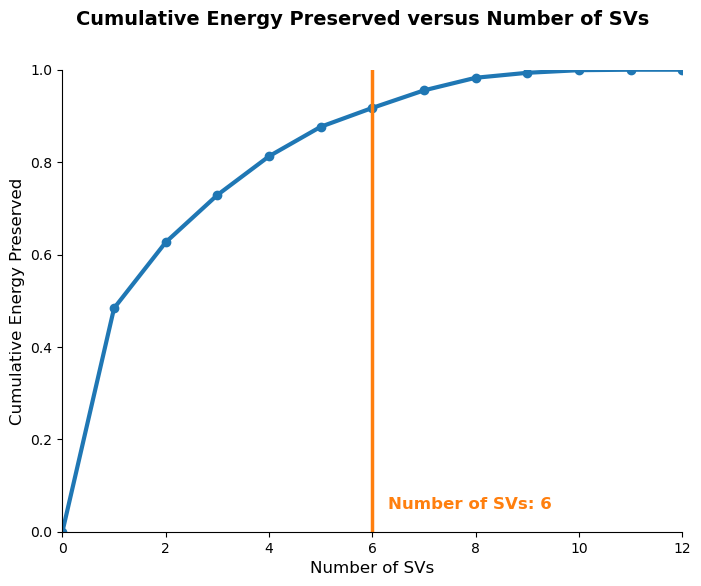

In [16]:
fig, ax, thresh = plot_energy_ratio(energy_ratio_ng);

In [17]:
truncated_semantic_vectors = semantic_vectors[:, :thresh]
truncated_semantic_vectors

array([[ 0.50701637,  0.77051384, -0.18183619,  0.06513761,  0.25701002,
         0.04265342],
       [ 0.84758893, -0.43527926,  0.06930705,  0.09327355,  0.11212838,
         0.19644492],
       [ 0.58434248, -0.48550807, -0.50829003, -0.09765183, -0.10506717,
         0.02449626],
       [ 0.77845368, -0.02818152,  0.23915499,  0.28029798, -0.12668314,
        -0.28185652],
       [ 0.87534719,  0.00302807,  0.01859261,  0.10463559,  0.15083971,
         0.36443507],
       [ 0.51551999,  0.70183554, -0.27147298, -0.03011707, -0.25668012,
        -0.16933299],
       [ 0.69125265, -0.14618234,  0.01163924,  0.36886299, -0.48516257,
        -0.05006003],
       [ 0.69783017,  0.2521    ,  0.45432567, -0.354937  ,  0.08805425,
         0.08703973],
       [ 0.55251912, -0.23797087, -0.52799679, -0.13180336,  0.41389997,
        -0.30559983],
       [ 0.55364972, -0.2185384 ,  0.43505964, -0.54036876, -0.02875178,
        -0.2516664 ],
       [ 0.7943799 ,  0.01598721,  0.24816735,  0.

In [18]:
W_ng = pd.DataFrame(svd_ng.components_, columns=df_tfidf.columns,
                 index=[f'SV {i + 1}' for i in range(df_tfidf.shape[0])])
W_ng

,battery,case,charging,comfortable,earbuds,easy,good,great,price,quality,sound,use
SV 1,0.226766,0.253742,0.222670,0.232537,0.266013,0.241547,0.305780,0.365928,0.286628,0.413188,0.325399,0.255460
SV 2,-0.041351,-0.271083,-0.216260,0.481593,0.059349,0.004650,-0.134590,0.685437,-0.228624,-0.144713,-0.046072,-0.281580
SV 3,0.260249,-0.472436,-0.267861,-0.294465,-0.208562,0.117293,0.242695,0.062272,-0.137792,0.595554,-0.234550,-0.043562
SV 4,0.259775,-0.095298,-0.028327,0.003906,0.203050,-0.143164,0.661139,-0.038279,-0.390673,-0.446604,-0.024072,0.263936
SV 5,0.028428,-0.025909,-0.342197,-0.390000,0.756385,-0.006644,-0.299626,0.117651,0.076438,-0.023191,-0.127046,0.176124
SV 6,0.096766,0.059154,0.426460,0.094411,0.063245,0.549906,-0.250991,-0.038278,-0.398724,0.001162,-0.470653,0.212133
SV 7,0.023476,-0.151561,0.040448,-0.348159,-0.413652,0.149306,-0.057986,0.434901,0.367305,-0.385306,-0.053080,0.426069
SV 8,-0.092373,-0.259053,0.105363,0.170267,-0.062253,-0.443351,-0.320344,-0.024822,-0.288176,0.240596,0.246688,0.615473
SV 9,-0.272631,-0.281211,-0.350717,0.133314,0.012615,0.616055,0.018979,-0.283304,-0.049026,-0.111123,0.458221,0.144203
SV 10,0.733448,0.232498,-0.185320,-0.093466,-0.180781,0.060429,-0.347047,-0.022816,-0.221763,-0.110181,0.369310,-0.099575


In [19]:
semantic_vectors = pd.DataFrame(semantic_vectors, columns=W_ng.index)
semantic_vectors

,SV 1,SV 2,SV 3,SV 4,SV 5,SV 6,SV 7,SV 8,SV 9,SV 10,SV 11,SV 12
0,0.507016,0.770514,-0.181836,0.065138,0.257010,0.042653,-0.015108,0.030296,-0.149939,-0.142516,0.011107,-0.000139
1,0.847589,-0.435279,0.069307,0.093274,0.112128,0.196445,0.036269,0.132642,0.046473,-0.022746,0.076618,0.001212
2,0.584342,-0.485508,-0.508290,-0.097652,-0.105067,0.024496,0.301637,0.203419,-0.101781,-0.007693,-0.022506,-0.001613
3,0.778454,-0.028182,0.239155,0.280298,-0.126683,-0.281857,0.314793,-0.199545,0.118933,-0.094276,-0.003989,-0.000382
4,0.875347,0.003028,0.018593,0.104636,0.150840,0.364435,-0.205122,-0.059973,0.142394,-0.007276,-0.029880,-0.002201
5,0.515520,0.701836,-0.271473,-0.030117,-0.256680,-0.169333,-0.012833,0.213414,0.135206,0.089303,0.023172,-0.000594
6,0.691253,-0.146182,0.011639,0.368863,-0.485163,-0.050060,-0.295972,-0.114619,-0.159137,0.022780,0.011641,-0.000450
7,0.697830,0.252100,0.454326,-0.354937,0.088054,0.087040,0.220491,-0.158168,-0.115170,0.120954,0.015127,-0.000933
8,0.552519,-0.237971,-0.527997,-0.131803,0.413900,-0.305600,-0.162077,-0.219296,0.009497,0.051532,0.011402,0.000042
9,0.553650,-0.218538,0.435060,-0.540369,-0.028752,-0.251666,-0.242915,0.187511,0.001325,-0.077597,-0.009148,-0.000514


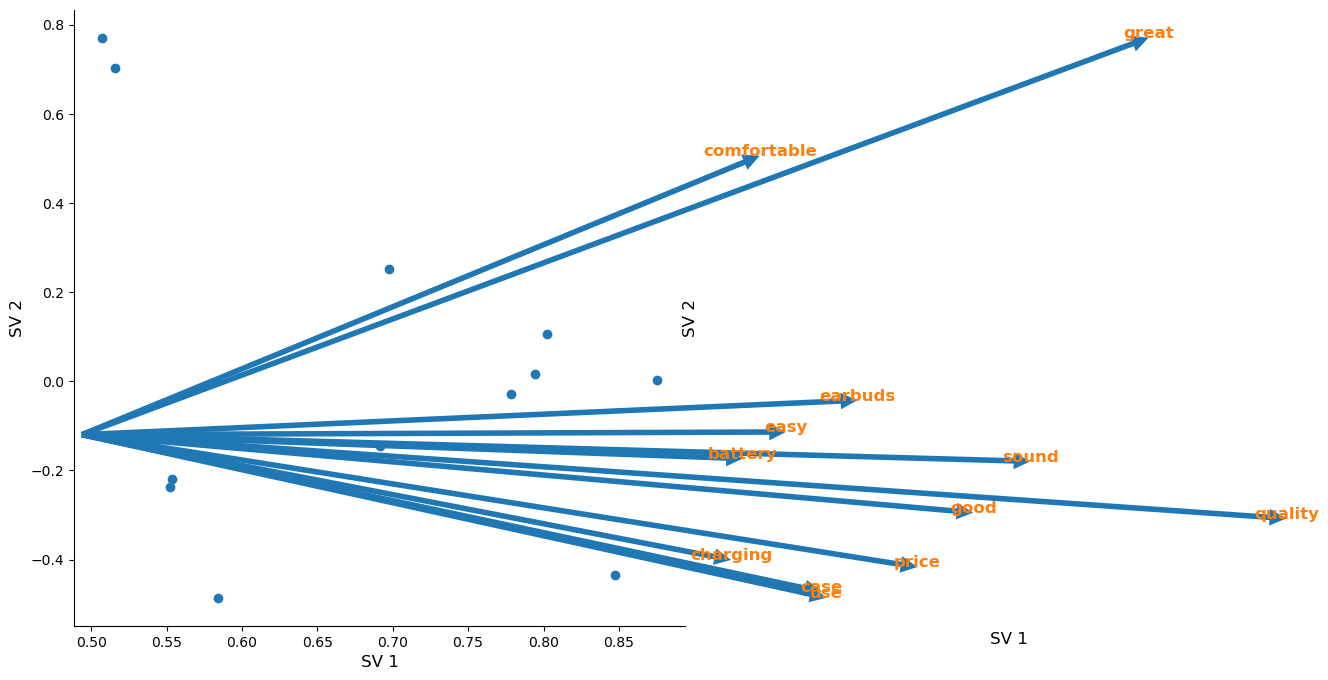

In [20]:
fig, axes = plot_principal_components(semantic_vectors, W_ng, 'SV 1', 'SV 2')

In [21]:
term_topic_matrix = pd.DataFrame(
    svd_ng.components_.T,
    index=df_tfidf.columns,
    columns=[f'SV {i + 1}' for i in range(df_tfidf.shape[0])])
term_topic_matrix

,SV 1,SV 2,SV 3,SV 4,SV 5,SV 6,SV 7,SV 8,SV 9,SV 10,SV 11,SV 12
battery,0.226766,-0.041351,0.260249,0.259775,0.028428,0.096766,0.023476,-0.092373,-0.272631,0.733448,0.234898,-0.353481
case,0.253742,-0.271083,-0.472436,-0.095298,-0.025909,0.059154,-0.151561,-0.259053,-0.281211,0.232498,0.114756,0.623938
charging,0.222670,-0.216260,-0.267861,-0.028327,-0.342197,0.426460,0.040448,0.105363,-0.350717,-0.185320,-0.450481,-0.398891
comfortable,0.232537,0.481593,-0.294465,0.003906,-0.390000,0.094411,-0.348159,0.170267,0.133314,-0.093466,0.517620,-0.147009
earbuds,0.266013,0.059349,-0.208562,0.203050,0.756385,0.063245,-0.413652,-0.062253,0.012615,-0.180781,-0.092699,-0.220117
easy,0.241547,0.004650,0.117293,-0.143164,-0.006644,0.549906,0.149306,-0.443351,0.616055,0.060429,-0.042332,0.033443
good,0.305780,-0.134590,0.242695,0.661139,-0.299626,-0.250991,-0.057986,-0.320344,0.018979,-0.347047,-0.029151,0.109415
great,0.365928,0.685437,0.062272,-0.038279,0.117651,-0.038278,0.434901,-0.024822,-0.283304,-0.022816,-0.239071,0.218930
price,0.286628,-0.228624,-0.137792,-0.390673,0.076438,-0.398724,0.367305,-0.288176,-0.049026,-0.221763,0.347404,-0.372705
quality,0.413188,-0.144713,0.595554,-0.446604,-0.023191,0.001162,-0.385306,0.240596,-0.111123,-0.110181,-0.013340,0.150474


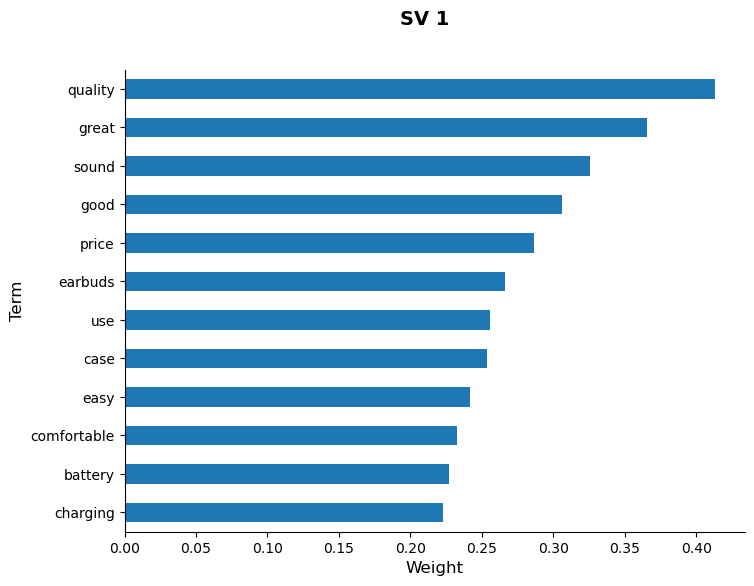

In [22]:
plot_topic_vector(term_topic_matrix, 'SV 1');

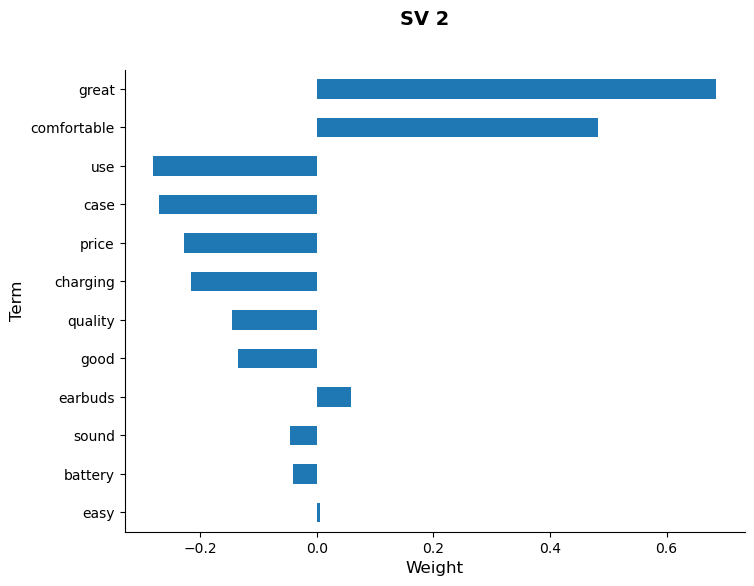

In [23]:
plot_topic_vector(term_topic_matrix, 'SV 2');

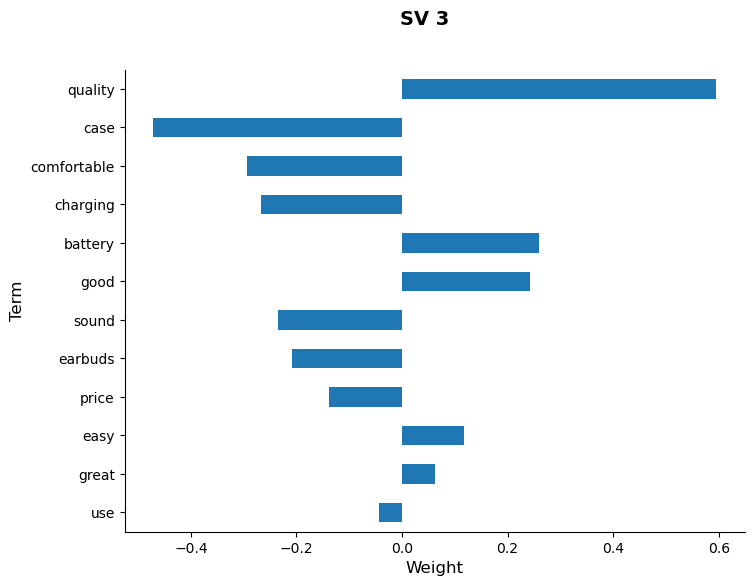

In [24]:
plot_topic_vector(term_topic_matrix, 'SV 3');

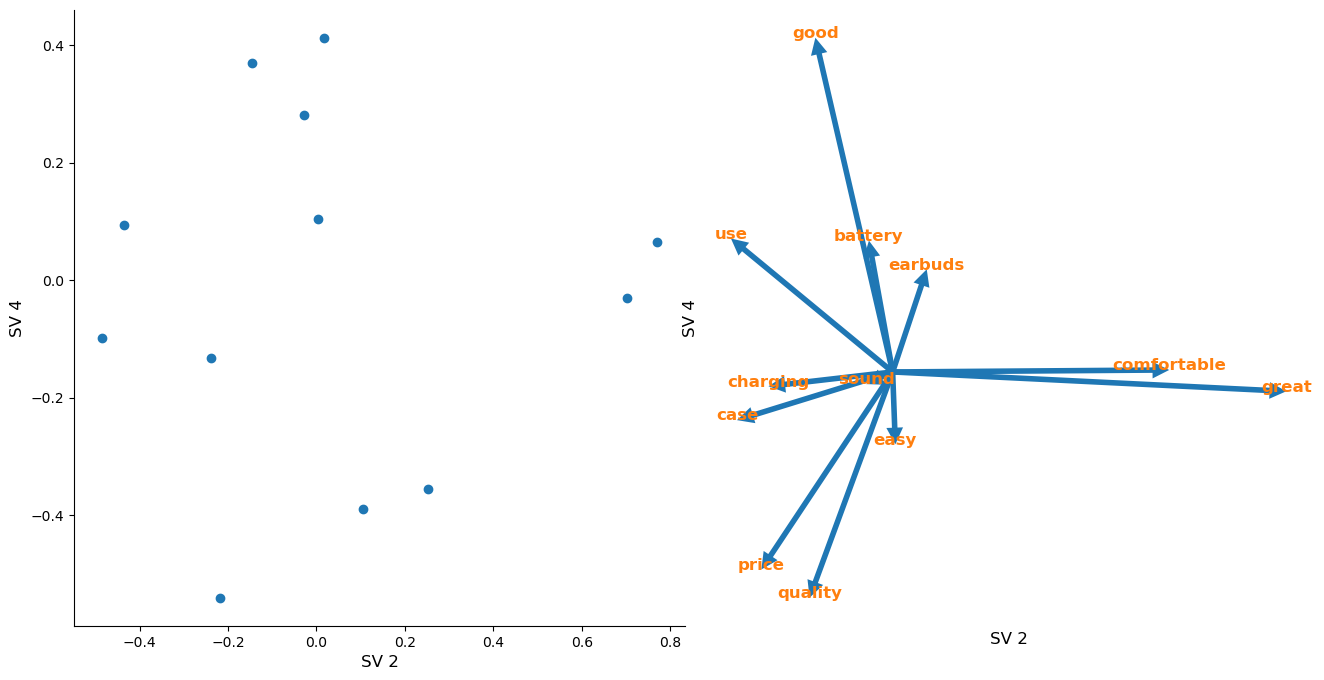

In [25]:
fig, axes = plot_principal_components(semantic_vectors, W_ng, 'SV 2', 'SV 4')